In [ ]:
'''
2025년 9월 7일 일요일 화이팅입니다!!!

오늘 배울 부분은 데이터 시각화이다.
지난학기 파이썬 수업이나 빅데이터 수업에서 들어 익숙한 내용이고,
이번 학기에도 데이터 분석 수업에서 자주 사용하게 될 기능이니
집중해서 듣고 확실히 익히도록 하자!!
'''

# 탐색적 데이터 분석 - 데이터 시각화

In [ ]:
'''
이번 수업에서 사용하게 될 라이브러리인 Matplotlib ,Seaborn, Plotly, Altair이다.
'''

In [1]:
'''
import warnings
# 경고창 제거
warnings.filterwarnings('ignore')
# 한글 글꼴 설정
rc('font', family='Malgun Gothic')
'''

## 시각화 과정에서 한글을 사용해보면 한글이 깨지며 무수한 경고들이 나오는 것을 볼 수 있다.
## 이를 방지하기 위해 강의에서는 위와 같은 폰트를 예시로 제시했으나,
## 나는 모든 경고를 무력화하는 것이 불안해 아래의 코드를 작성했다.

import matplotlib.pyplot as plt
import warnings
import pandas as pd

# 1. 선별적 경고 무시
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')
warnings.filterwarnings('ignore', message='.*font.*')

# 2. 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 3. 중요한 경고는 여전히 볼 수 있음
print("현재 경고 필터:", warnings.filters[:3])  # 설정된 필터 확인

현재 경고 필터: [('ignore', re.compile('.*font.*', re.IGNORECASE), <class 'Warning'>, None, 0), ('ignore', None, <class 'FutureWarning'>, re.compile('pandas'), 0), ('ignore', re.compile('numpy.ndarray size changed', re.IGNORECASE), <class 'Warning'>, None, 0)]


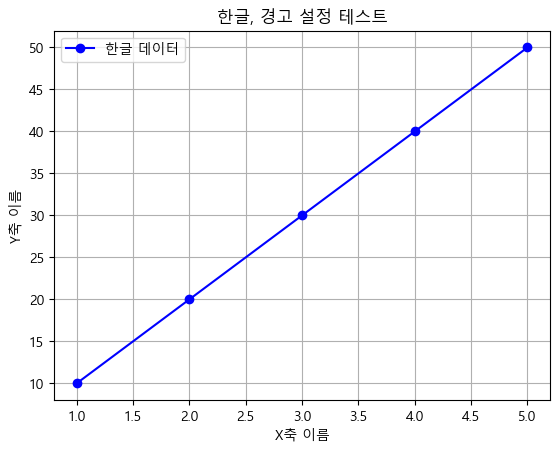

In [4]:
# 데이터 준비
x = [1, 2, 3, 4, 5]
y = [10, 20, 30, 40, 50]

# 그래프 그리기
plt.plot(x, y, label="한글 데이터", color='blue', marker='o')
plt.title("한글, 경고 설정 테스트")  # 그래프 제목
plt.xlabel("X축 이름")              # X축 레이블
plt.ylabel("Y축 이름")              # Y축 레이블
plt.legend()                        # 범례 표시
plt.grid(True)                      # 격자 표시
plt.show()

## 1. Matplotlib

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("datasets/heart.csv")
column_mapping = {
    'age': '나이',
    'sex': '성별', 
    'cp': '흉통유형',
    'trtbps': '안정시혈압',
    'chol': '콜레스테롤',
    'fbs': '공복혈당',
    'restecg': '안정시심전도',
    'thalachh': '최대심박수',
    'exng': '운동유발협심증',
    'oldpeak': 'ST하강',
    'slp': 'ST기울기',
    'caa': '주요혈관수',
    'thall': '지중해빈혈',
    'output': '심장병여부'
}
df.rename(columns=column_mapping, inplace=True)

print(df.head())

   나이  성별  흉통유형  안정시혈압  콜레스테롤  공복혈당  안정시심전도  최대심박수  운동유발협심증  ST하강  ST기울기  \
0  63   1     3    145    233     1       0    150        0   2.3      0   
1  37   1     2    130    250     0       1    187        0   3.5      0   
2  41   0     1    130    204     0       0    172        0   1.4      2   
3  56   1     1    120    236     0       1    178        0   0.8      2   
4  57   0     0    120    354     0       1    163        1   0.6      2   

   주요혈관수  지중해빈혈  심장병여부  
0      0      1      1  
1      0      2      1  
2      0      2      1  
3      0      2      1  
4      0      2      1  


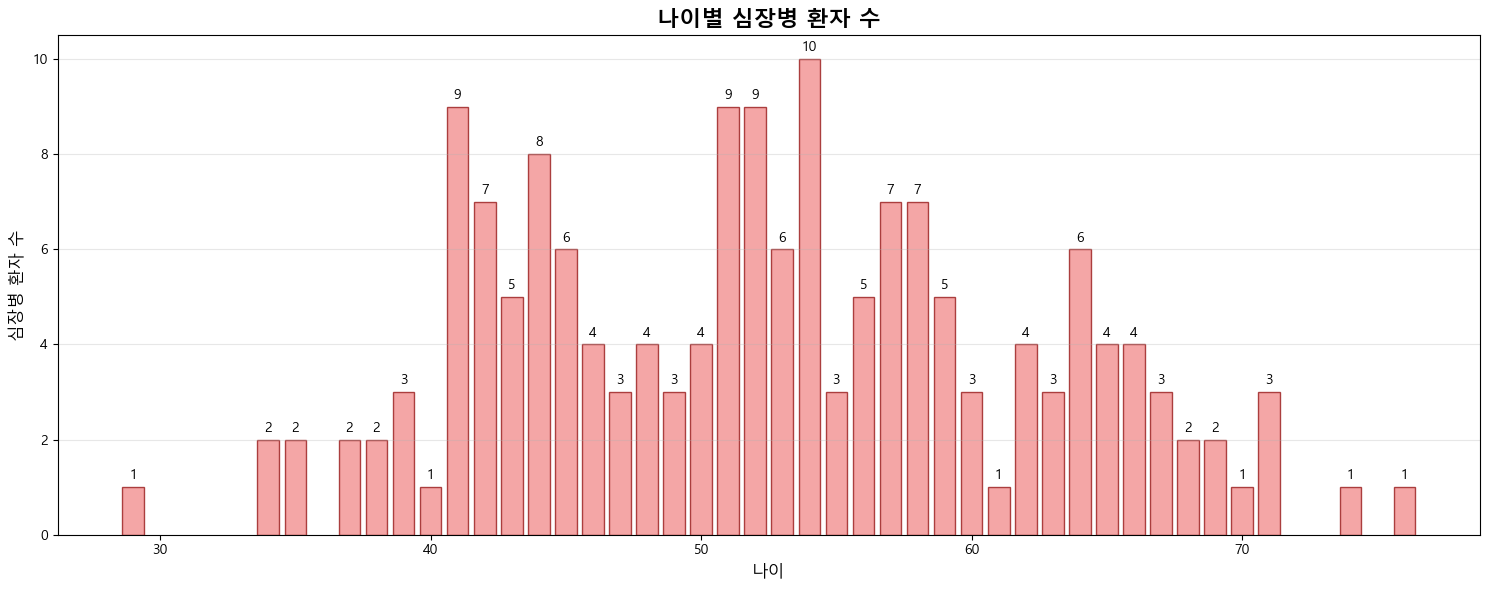

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 나이별 심장병 환자 수 계산
age_disease_count = df[df['심장병여부'] == 1]['나이'].value_counts().sort_index()

# 막대 그래프 생성
plt.figure(figsize=(15, 6))
plt.bar(age_disease_count.index, age_disease_count.values, 
        color='lightcoral', alpha=0.7, edgecolor='darkred')

plt.title('나이별 심장병 환자 수', fontsize=16, fontweight='bold')
plt.xlabel('나이', fontsize=12)
plt.ylabel('심장병 환자 수', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 막대 위에 숫자 표시
for age, count in zip(age_disease_count.index, age_disease_count.values):
    plt.text(age, count + 0.1, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 2. Seaborn

In [55]:
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

df.head()

,나이,성별,흉통유형,안정시혈압,콜레스테롤,공복혈당,안정시심전도,최대심박수,운동유발협심증,ST하강,ST기울기,주요혈관수,지중해빈혈,심장병여부
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


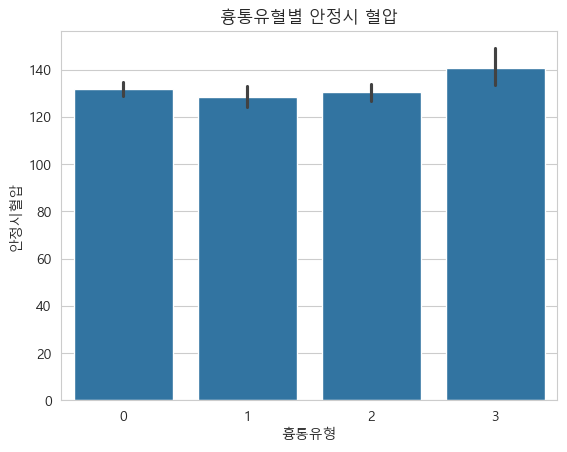

In [25]:
sns.barplot(x = df['흉통유형'], y = df['안정시혈압'], data= df)
plt.title('흉통유혈별 안정시 혈압')
plt.show()

<Axes: xlabel='흉통유형'>

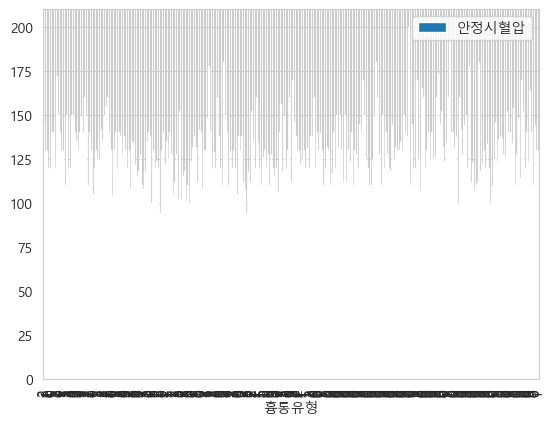

In [ ]:
df.plot(x= '흉통유형', y= '안정시혈압', kind='bar')

'''
음... 좀 더 공부해보고 와야겠다.
여기 강사는 기본적인 것들 외에는 못하는 것 같은데..??
'''

<Axes: xlabel='흉통유형'>

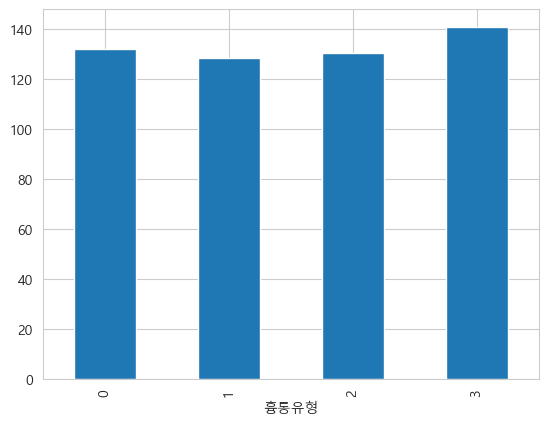

In [ ]:
group = df.groupby('흉통유형')['안정시혈압'].mean()
group.plot(x='흉통유형', y='안정시혈압', kind= 'bar')

C:\Users\16Z90P\AppData\Local\Temp\ipykernel_37732\3832675034.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




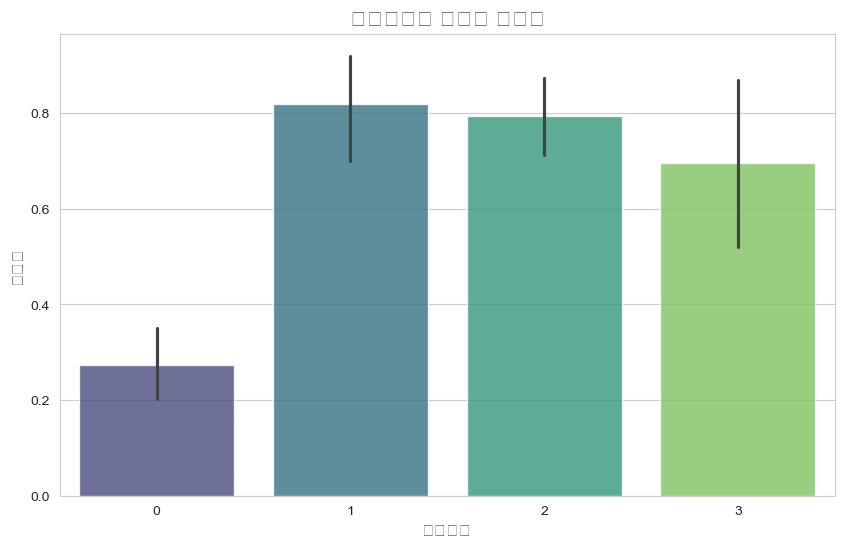

In [33]:
# 기본 막대그래프 (발병률 자동 계산)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='흉통유형', y='심장병여부', 
            palette='viridis', alpha=0.8)

plt.title('흉통유형별 심장병 발병률', fontsize=16, fontweight='bold')
plt.xlabel('흉통유형', fontsize=12)
plt.ylabel('발병률', fontsize=12)
plt.show()

Text(0.5, 1.0, '나이대 별 표본 수')

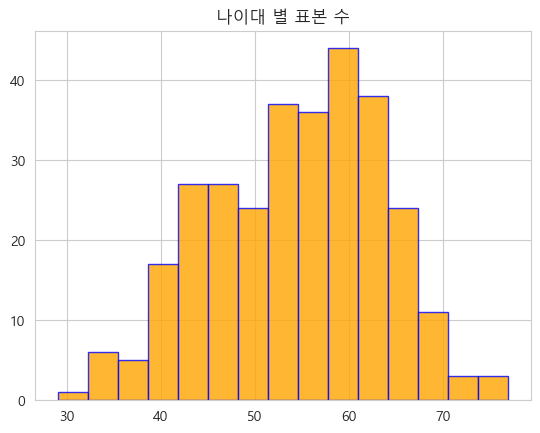

In [49]:
plt.hist(df['나이'], bins=15, color='orange', alpha= 0.8, edgecolor='blue')
plt.xlabel= '나이'
plt.ylabel= '표본 수'
plt.grid(True)
plt.title('나이대 별 표본 수')

Text(0.5, 1.0, '안정시 혈압 박스플롯')

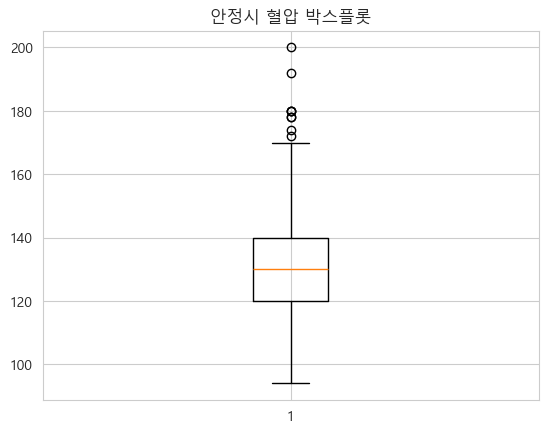

In [59]:
plt.boxplot(df['안정시혈압'])
plt.title('안정시 혈압 박스플롯')

<Axes: xlabel='성별', ylabel='안정시혈압'>

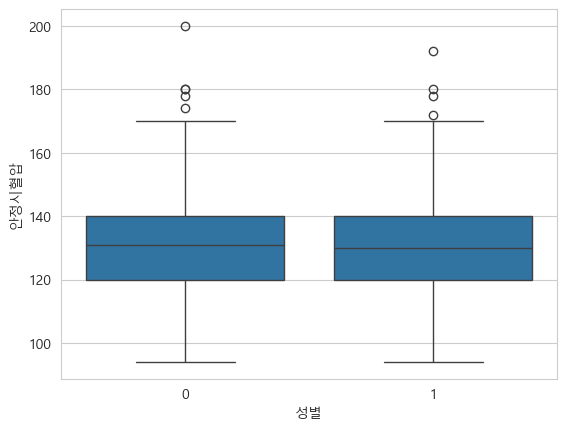

In [ ]:
sns.boxplot(x='성별', y='안정시혈압', data=df)

In [ ]:
# 매개변수 모르겠으면 ? 치면 알려줌

sns.boxplot?

Signature:
sns.boxplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    order=None,
    hue_order=None,
    orient=None,
    color=None,
    palette=None,
    saturation=0.75,
    fill=True,
    dodge='auto',
    width=0.8,
    gap=0,
    whis=1.5,
    linecolor='auto',
    linewidth=None,
    fliersize=None,
    hue_norm=None,
    native_scale=False,
    log_scale=None,
    formatter=None,
    legend='auto',
    ax=None,
    **kwargs,
)
Docstring:
Draw a box plot to show distributions with respect to categories.

A box plot (or box-and-whisker plot) shows the distribution of quantitative
data in a way that facilitates comparisons between variables or across
levels of a categorical variable. The box shows the quartiles of the
dataset while the whiskers extend to show the rest of the distribution,
except for points that are determined to be "outliers" using a method
that is a function of the inter-quartile range.

See the :ref:`tutorial <categorical_tutorial>` for more i

In [65]:
plt.boxplot?

Signature:
plt.boxplot(
    x: 'ArrayLike | Sequence[ArrayLike]',
    *,
    notch: 'bool | None' = None,
    sym: 'str | None' = None,
    vert: 'bool | None' = None,
    orientation: "Literal['vertical', 'horizontal']" = 'vertical',
    whis: 'float | tuple[float, float] | None' = None,
    positions: 'ArrayLike | None' = None,
    widths: 'float | ArrayLike | None' = None,
    patch_artist: 'bool | None' = None,
    bootstrap: 'int | None' = None,
    usermedians: 'ArrayLike | None' = None,
    conf_intervals: 'ArrayLike | None' = None,
    meanline: 'bool | None' = None,
    showmeans: 'bool | None' = None,
    showcaps: 'bool | None' = None,
    showbox: 'bool | None' = None,
    showfliers: 'bool | None' = None,
    boxprops: 'dict[str, Any] | None' = None,
    tick_labels: 'Sequence[str] | None' = None,
    flierprops: 'dict[str, Any] | None' = None,
    medianprops: 'dict[str, Any] | None' = None,
    meanprops: 'dict[str, Any] | None' = None,
    capprops: 'dict[str, Any] | No

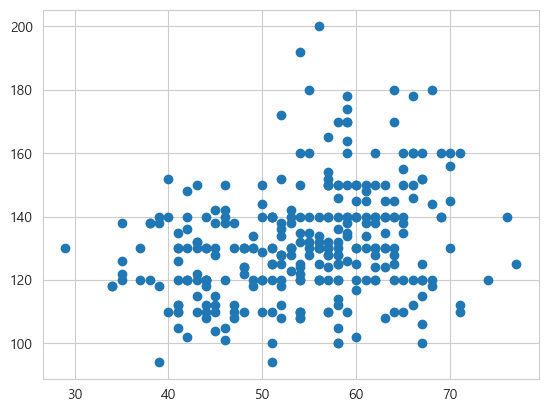

In [67]:
plt.scatter(df['나이'], df['안정시혈압'])

<Axes: xlabel='흉통유형', ylabel='count'>

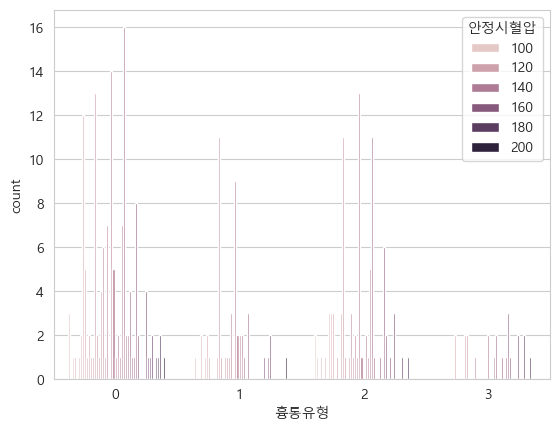

In [71]:
sns.countplot(x=df['흉통유형'], hue=df['안정시혈압'], data = df)

<Axes: xlabel='나이', ylabel='count'>

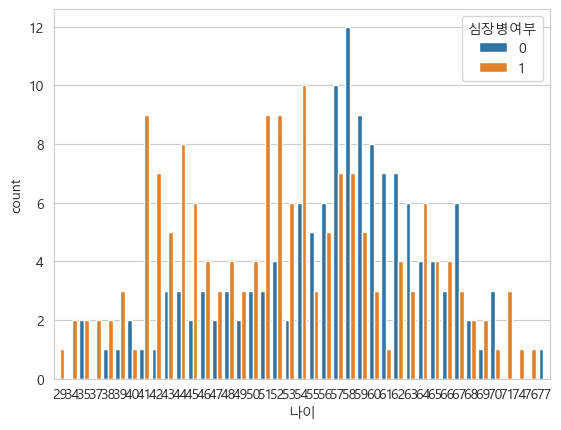

In [ ]:
## 오호라~ 요즘 많이 출제된다는 countplot이다.

sns.countplot(x= df['나이'], hue=df['심장병여부'], data=df)

## 3. Plotly

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

# 샘플 데이터 생성
dates = pd.date_range('2024-01-01', periods=100, freq='D')
매출 = np.random.randint(100, 200, 100) + np.sin(np.arange(100) * 0.1) * 20
이익률 = np.random.rand(100) * 10 + 5

# 기본 선 그래프
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates, y=매출, mode='lines', name='매출'))
fig.update_layout(title='매출 추이', xaxis_title='날짜', yaxis_title='매출(억원)')
fig.show()

## 4. Pandas Plot